In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
sudan = pd.read_csv("data/sudan_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")
nigeria = pd.read_csv("data/nigeria_clean.csv")

In [3]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [4]:
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

In [6]:

if "date" not in df.columns:
    df["date"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["DOY"].astype(str),
        format="%Y%j"
    )


if "Month" not in df.columns:
    df["Month"] = df["date"].dt.month


temp_monthly = df.groupby(["Country", "date"])["T2M"].mean().reset_index()



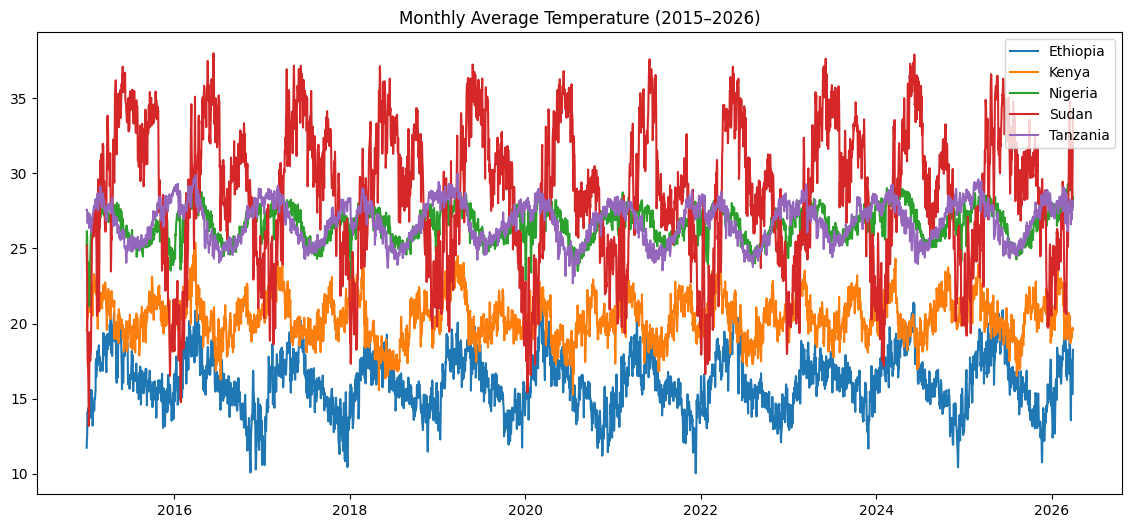

In [7]:
plt.figure(figsize=(14,6))

for country in temp_monthly["Country"].unique():
    subset = temp_monthly[temp_monthly["Country"] == country]
    plt.plot(subset["date"], subset["T2M"], label=country)

plt.title("Monthly Average Temperature (2015–2026)")
plt.legend()
plt.show()

In [8]:
temp_stats = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_stats

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


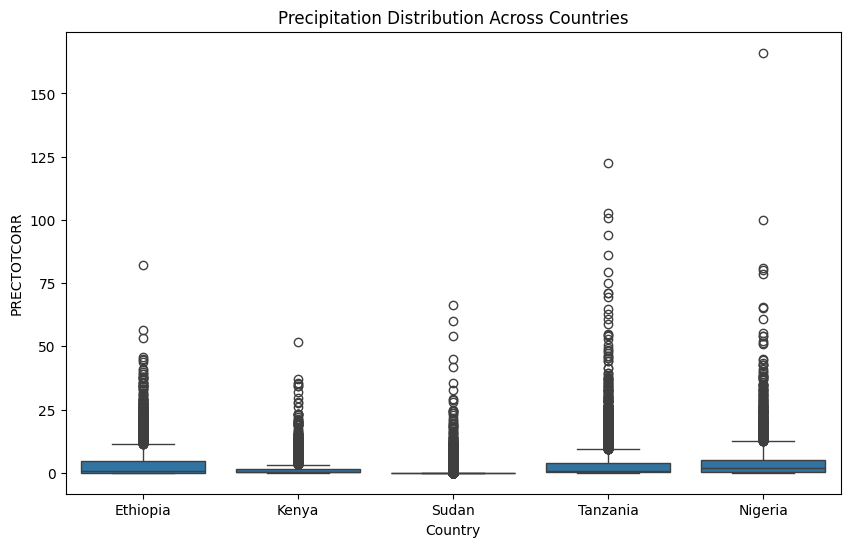

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution Across Countries")
plt.show()

In [10]:
precip_stats = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_stats

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [11]:
heat = df[df["T2M_MAX"] > 35]

heat_events = heat.groupby("Country").size()
heat_events

Country
Sudan    2694
dtype: int64

In [12]:
dry = df[df["PRECTOTCORR"] < 1]

dry_events = dry.groupby("Country").size()
dry_events

Country
Ethiopia    2161
Kenya       2831
Nigeria     1595
Sudan       3696
Tanzania    2303
dtype: int64

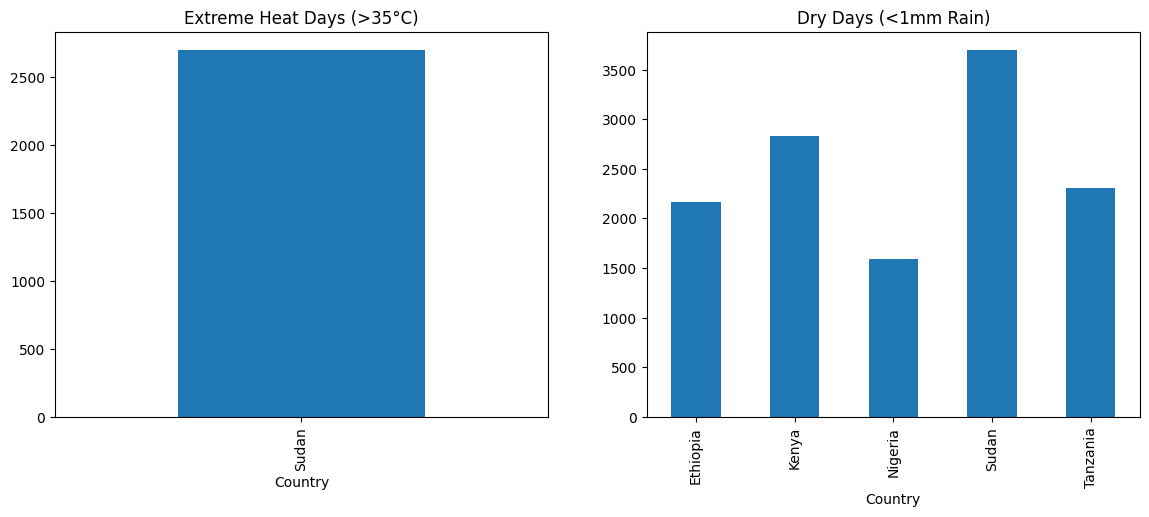

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

heat_events.plot(kind="bar", ax=ax[0], title="Extreme Heat Days (>35°C)")
dry_events.plot(kind="bar", ax=ax[1], title="Dry Days (<1mm Rain)")

plt.show()

In [14]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 18938.7456970699
p-value: 0.0


p < 0.05 → countries significantly different